### Histograms
- 도수분포표: 특정 구간에 속하는 자료의 개수를 표현
- 히스토그램: 도수분포표를 시각화하여 막대그래프로 표현, 하지만 bar plot과는 다름(일반 막대그래프와 다름)

- bar plot (막대그래프) : 표현 값에 비례하여 높이와 길이를 지닌 직사각형 막대로
             범주형 데이터를 표현하는 차트나 그래프, 합계, 평균 등의 수치를 시각화
- hist plot (히스토그램) : 구간별 빈도수를 표현
- density plot (정규분포) : 확률 밀도 함수 - 확률 변수의 밀도를 표현

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

%matplotlib inline

# 한글폰트 사용시 그래프에서 마이너스 폰트 깨지는 문제에 대한 대처
mpl.rcParams['axes.unicode_minus'] = False

In [ ]:
df4 = pd.DataFrame({'a': np.random.randn(1000) + 1,
                    'b': np.random.randn(1000),
                    'c': np.random.randn(1000) - 1},
                    columns=['a', 'b', 'c'])

df4.head()

,a,b,c
0,1.028436,0.456359,-0.370816
1,-0.419101,2.029506,-2.107207
2,2.142423,-0.458932,-1.091900
3,1.318580,-0.904109,-1.163984
4,0.623791,1.001367,0.840944


<Axes: ylabel='Frequency'>

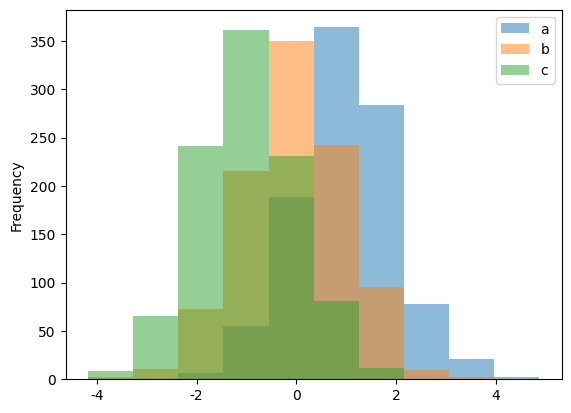

In [ ]:
# alpha=0.5: 투명도 0.5로 설정
# bin: 전체 데이터 범위를 나눈 구간
# 기본 설정인 10개의 bin으로 Frequency 생성
df4.plot.hist(alpha=0.5)

<Axes: ylabel='Frequency'>

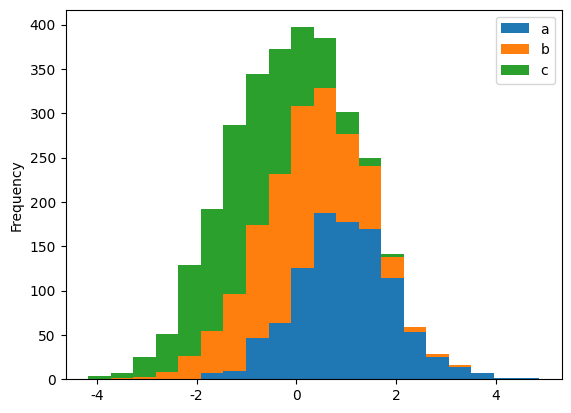

In [ ]:
# a, b, c를 쌓아올림
# bin값에 따라 Frequency가 달라짐
df4.plot.hist(stacked=True, bins=20)

<Axes: xlabel='Frequency'>

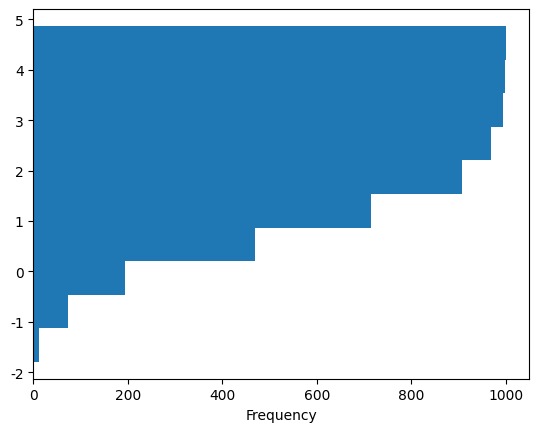

In [ ]:
# orientation='horizontal': x축이 Frequency, y축이 bins로 변경(서로 바꿈)
# cumulative=True: 이전 구간의 bin의 빈도수를 모두 합쳐서 보여줌(누적)
df4['a'].plot.hist(orientation='horizontal', cumulative=True)

<Axes: >

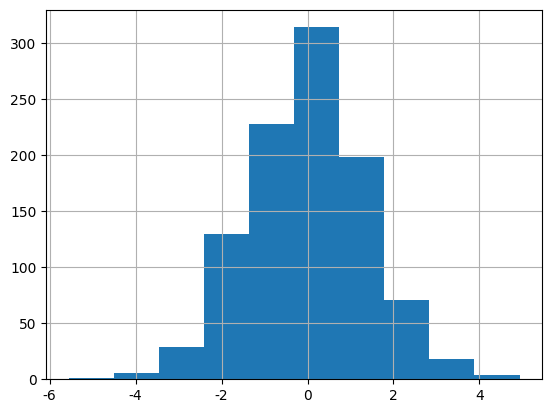

In [ ]:
df4['a'].diff().hist()

In [ ]:
# 'a'컬럼의 데이터를 아래로 한 칸씩 이동(shift)
df4['a_shift'] = df4['a'].shift(1)

# 현재의 a값에서 바로 위 행의 값인 a_shift를 뺀 결과
df4['a_minus'] = df4['a'] - df4['a_shift']

# Pandas에서 제공하는 함수, 현재 행과 이전 행의 차이를 계산
df4['a_diff'] = df4['a'].diff()

df4[['a', 'a_shift', 'a_minus', 'a_diff']]

,a,a_shift,a_minus,a_diff
0,1.028436,NaN,NaN,NaN
1,-0.419101,1.028436,-1.447537,-1.447537
2,2.142423,-0.419101,2.561524,2.561524
3,1.318580,2.142423,-0.823843,-0.823843
4,0.623791,1.318580,-0.694790,-0.694790
...,...,...,...,...
995,2.601667,0.127711,2.473956,2.473956
996,-0.203602,2.601667,-2.805269,-2.805269
997,2.500059,-0.203602,2.703661,2.703661
998,1.133993,2.500059,-1.366066,-1.366066


array([[<Axes: title={'center': 'a'}>, <Axes: title={'center': 'b'}>],
       [<Axes: title={'center': 'c'}>, <Axes: >]], dtype=object)

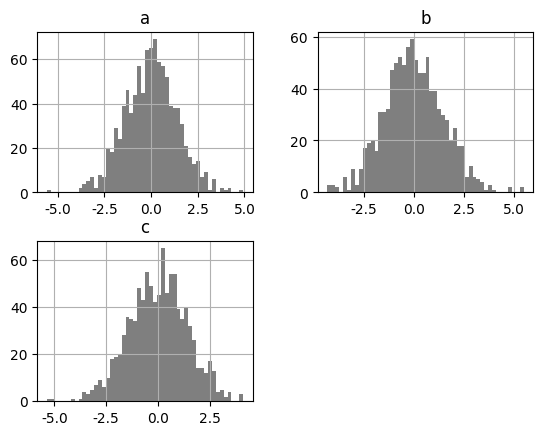

In [16]:
df4[['a', 'b', 'c']].diff().hist(color='k', alpha=0.5, bins=50)

In [27]:
data = pd.Series(np.random.randn(1000))

# 'a'열: 평균 0, 표준편차 1인 표준정규분포를 따르는 실수 1000개
# 'b'열: 0, 1, 2, 3 중 하나의 값을 갖는 정수 1000개
data = pd.DataFrame({'a': np.random.randn(1000),
                     'b': np.random.randint(0, 4, 1000)})

data.head()

,a,b
0,-1.347166,3
1,0.518449,3
2,-0.946126,3
3,-0.751252,0
4,0.972847,1


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

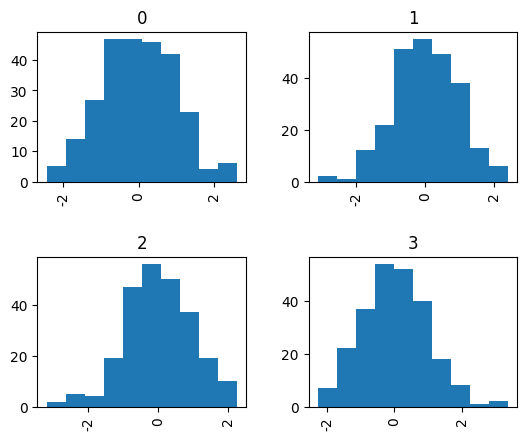

In [ ]:
# data의 'b'열의 값들을 기준으로 데이터를 그룹핑
# figsize=(6, 5): 전체 그래프 창의 크기 설정(가로 6인치, 세로 5인치)
# x축은 a열의 값에 대한 구간, y축은 a열의 값들에 대한 빈도수
data['a'].hist(by=data['b'], figsize=(6, 5))